# Models evaluator notebook  

## Load and prepare data

### Load data

In [2]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from more_itertools import unique_justseen
from aymurai.database.utils import text_to_uuid
from aymurai.api.endpoints.routers.misc.document_extract import extraction

IS_OPENAI_FILE = True # or False
IS_MAIN_DF = 'documents-02-08-sin05-conOpenAI.csv' # or False
OPENAI_PREDICTION_FILE = "predictions_openai-alldocs.pkl"
AYMURAI_JSONS_PATH = '/Users/sofi/Desktop/collectiveai/projects/AymurAI' # '/Users/sofi/Desktop/collectiveai/projects/AymurAI/'
DOCS_PATH = '/Users/sofi/Desktop/collectiveai/projects/AymurAI/backend/resources/data/sample/'

In [3]:
if IS_OPENAI_FILE:
    try:
        with open(OPENAI_PREDICTION_FILE, "rb") as file:
            predictions = pickle.load(file)
    except Exception as e:
        print(f'There is no file named {OPENAI_PREDICTION_FILE}, please redefine OPENAI_PREDICTION_FILE variable')
else:
    print('There is no file of predictions')

if IS_MAIN_DF:
    df = pd.read_csv(IS_MAIN_DF)
else:
    print('Calculating main df from jsons from AimurAI outputs')
    json_files = [f for f in os.listdir(AYMURAI_JSONS_PATH) if f.endswith('.json')]
    para_files = [f for f in json_files if f.startswith('anonymization_paragraph')]
    para_df = pd.concat([pd.read_json(AYMURAI_JSONS_PATH + fname) for fname in para_files], ignore_index=True)

    doc_files = [f for f in json_files if f.startswith('anonymization_document') and not 'paragraph' in f]
    doc_df = pd.concat([pd.read_json(AYMURAI_JSONS_PATH + fname) for fname in doc_files], ignore_index=True)

    doc_para_files = [f for f in json_files if f.startswith('anonymization_document_paragraph')]
    doc_para_df = pd.concat([pd.read_json(AYMURAI_JSONS_PATH + fname) for fname in doc_para_files], ignore_index=True)

    doc_df = doc_df.copy()
    doc_para_df = doc_para_df.copy()
    doc_df['id'] = doc_df['id'].astype(str)
    doc_para_df['document_id'] = doc_para_df['document_id'].astype(str)


    merged_df = pd.merge(
        doc_para_df,
        doc_df[['id', 'created_at', 'name']],
        left_on='document_id',
        right_on='id',
        how='left'
    ).rename(columns={'id_x': 'id'}).drop(columns=['id_y'])

    df = pd.merge(
        para_df,
        merged_df,
        left_on='id',
        right_on='paragraph_id',
        how='left'
    )




In [4]:
df.head(3)

,text_x,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,148,233,document-02.docx
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,85,document-04.docx
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,62,147,document-08.docx


### Function definitions

In [ ]:
def metrics_per_entity_by_span(df):
    # acumula TP/FP/FN por entidad (label)
    counts = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for i in range(len(df)):
        # cada celda puede ser una lista de dicts; si falla, lista vacía
        try:
            val_list = eval(df.validation.iloc[i])
        except:
            val_list = []
        try:
            pred_list = eval(df.prediction.iloc[i])
        except:
            pred_list = []
            
        # sets de spans por label: {(start, end), ...}
        val_spans = defaultdict(set)
        pred_spans = defaultdict(set)

        # VALIDATION (val)
        for v in (val_list or []):
            if not isinstance(v, dict):
                continue
            lab = (v.get('attrs', {}).get('aymurai_label', None)) or v.get('label', None)
            s = v.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = v.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                val_spans[lab].add((int(s), int(e)))
                #print('validation:')
                #print(lab, s, e)
        #print('val_spans: ', val_spans)

        # PREDICTIONS
        for p in (pred_list or []):
            if not isinstance(p, dict):
                continue
            lab = (p.get('attrs', {}).get('aymurai_label', None)) or p.get('label', None)
            s = p.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = p.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                pred_spans[lab].add((int(s), int(e)))
                #print('prediction:')
                #print(lab, s, e)
        #print('pred_spans: ', pred_spans)
        # actualizar TP/FP/FN por label en esta fila
        for lab in set(list(val_spans.keys()) + list(pred_spans.keys())):
            vs = val_spans.get(lab, set())
            ps = pred_spans.get(lab, set())
            tp = len(ps & vs)
            fp = len(ps - vs)
            fn = len(vs - ps)
            counts[lab]['tp'] += tp
            counts[lab]['fp'] += fp
            counts[lab]['fn'] += fn

    # calcular métricas por label + micro/macro
    out = {'per_label': {}, 'micro': {}, 'macro': {}}
    micro_tp = micro_fp = micro_fn = 0

    for lab, c in counts.items():
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support   = tp + fn  # cantidad de entidades de referencia (validation) para ese label
        out['per_label'][lab] = {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}
        micro_tp += tp; micro_fp += fp; micro_fn += fn

    # micro
    micro_p = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_r = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0
    out['micro'] = {'precision': micro_p, 'recall': micro_r, 'f1': micro_f, 'support': micro_tp + micro_fn}

    # macro (promedio simple entre labels presentes)
    if out['per_label']:
        L = len(out['per_label'])
        macro_p = sum(m['precision'] for m in out['per_label'].values()) / L
        macro_r = sum(m['recall']    for m in out['per_label'].values()) / L
        macro_f = sum(m['f1']        for m in out['per_label'].values()) / L
    else:
        macro_p = macro_r = macro_f = 0.0
    out['macro'] = {'precision': macro_p, 'recall': macro_r, 'f1': macro_f}

    return out
def metrics_for_label(df, target = 'text'):
    tp, fp, fn = 0, 0, 0
    for i in range(len(df)):
        try:
            val = eval(df.validation.iloc[i])[0]
        except:
            val = []
        try:
            pred = eval(df.prediction.iloc[i])[0]
        except:
            pred = []
        
        if target == 'text':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            pred_set = set((text_pred,))
            val_set = set((text_val,))

        elif target == 'label':
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((label_pred,))
            val_set = set((label_val,))

        elif target == 'both':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((text_pred, label_pred))
            val_set = set((text_val, label_val))

        else:
            raise ValueError("Target must be one of 'text', 'label', or 'both'")
        if len(pred_set)>0 or len(val_set)>0: 
            tp += len(pred_set & val_set)
            fp += len(pred_set - val_set)
            fn += len(val_set - pred_set)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / ( tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (recall + precision) > 0 else 0

    return {'recall': recall, 'precision': precision, 'f1': f1}

def _metrics_to_df(out):
    rows = []
    for lab, m in out.get('per_label', {}).items():
        rows.append({
            'label': str(lab),
            'precision': float(m.get('precision', 0) or 0),
            'recall':    float(m.get('recall', 0) or 0),
            'f1':        float(m.get('f1', 0) or 0),
            'support':   m.get('support', 0)
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        # Evita crash si support viene como NaN/None/str
        df['support'] = pd.to_numeric(df['support'], errors='coerce').fillna(0).astype(int)
        df = df.sort_values('support', ascending=False).reset_index(drop=True)
    return df
def plot_per_label_bars(out, top=None, sort_by='support', aclaration_title='', alphabetical=False):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    if alphabetical:
        df = df.sort_values('label', ascending=True)
    elif sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False)
    if top:
        df = df.head(top)

    labels = df['label'].tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(labels)*0.9), 5),dpi = 150)
    ax.bar(x - width, df['precision'].values, width, label='Precision')
    ax.bar(x,         df['recall'].values,    width, label='Recall')
    ax.bar(x + width, df['f1'].values,        width, label='F1')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Per-label Precision / Recall / F1 '+ aclaration_title)
    ax.legend(loc = 'best')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar support arriba del rango actual del eje (sin asumir [0,1])
    y_top = ax.get_ylim()[1]
    y_text = y_top * 0.8
    for i, s in enumerate(df['support'].values):
        ax.text(i, y_text, f'n={int(s)}', ha='center', va='top', fontsize=11)

    plt.tight_layout()
    plt.show()

def plot_pr_scatter(out, min_support=1, annotate_top=None):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    df = df[df['support'] >= min_support].copy()
    if df.empty:
        print("No points after min_support filter."); 
        return

    # tamaños relativos según support (evita división por cero)
    max_sup = df['support'].max()
    if max_sup <= 0:
        size = np.full(len(df), 100.0)
    else:
        size = 100 * (0.3 + 0.7 * (df['support'] / max_sup))

    fig, ax = plt.subplots(figsize=(6, 6),dpi = 150)
    ax.scatter(df['recall'].values, df['precision'].values, s=size, alpha=0.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title('Precision vs Recall by Label (size ~ support)')
    ax.set_ylim(0, 1.4)

    # Anotar los top por support
    if annotate_top:
        top_df = df.sort_values('support', ascending=False).head(annotate_top)
    else:
        top_df = df.sort_values('support', ascending=False)

    for _, r in top_df.iterrows():
        ax.annotate(r['label'], (r['recall'], r['precision']), textcoords='offset points', xytext=(5, 5))

    plt.tight_layout()
    plt.show()

def plot_micro_macro(out):
    mm = out.get('micro', {}) or {}
    ma = out.get('macro', {}) or {}
    metrics = ['precision', 'recall', 'f1']
    micro_vals = [float(mm.get(m, 0) or 0) for m in metrics]
    macro_vals = [float(ma.get(m, 0) or 0) for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4),dpi = 150)
    b1 = ax.bar(x - width/2, micro_vals, width, label='Micro')
    b2 = ax.bar(x + width/2, macro_vals, width, label='Macro')

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_title('Micro vs Macro')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar valores respetando límites del eje
    y_top = ax.get_ylim()[1]
    for i, v in enumerate(micro_vals):
        ax.text(i - width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(macro_vals):
        ax.text(i + width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()



In [165]:
# TN es importante pero no cuenta en precision/recall/f1

# Example to visualize the actions of previuos functions

vs = {(312, 323), (400, 412), (55, 66), (238, 250)}
ps = {(312, 323), (423, 412), (55, 66), (238, 250)}
print(vs & ps, vs - ps, ps - vs)

{(312, 323), (55, 66), (238, 250)} {(400, 412)} {(423, 412)}


## Performance metrics calculation

### Prepare dataset

Definition of files to analize: 
- df_main: AymurAI output documents 01 to 08 without 05, 

- df_main_dropdup: df_main without duplicate paragraphs,

- df_main_openai: df_main with the prediction of openai though Langextraxt (only if OPENAI_PREDICTION_FILE = True )

In [166]:
df_main = df[df['name'].fillna('').str.startswith('document') & (df['name']!= 'document-09.docx')]
#df_main.to_csv('documents-02-08-sin05.csv', index=False)
set(df_main.name)
df_main_dropdup = df_main.drop_duplicates(subset='text', keep='first')

### Calculate metrics

#### With duplicated paragraph 

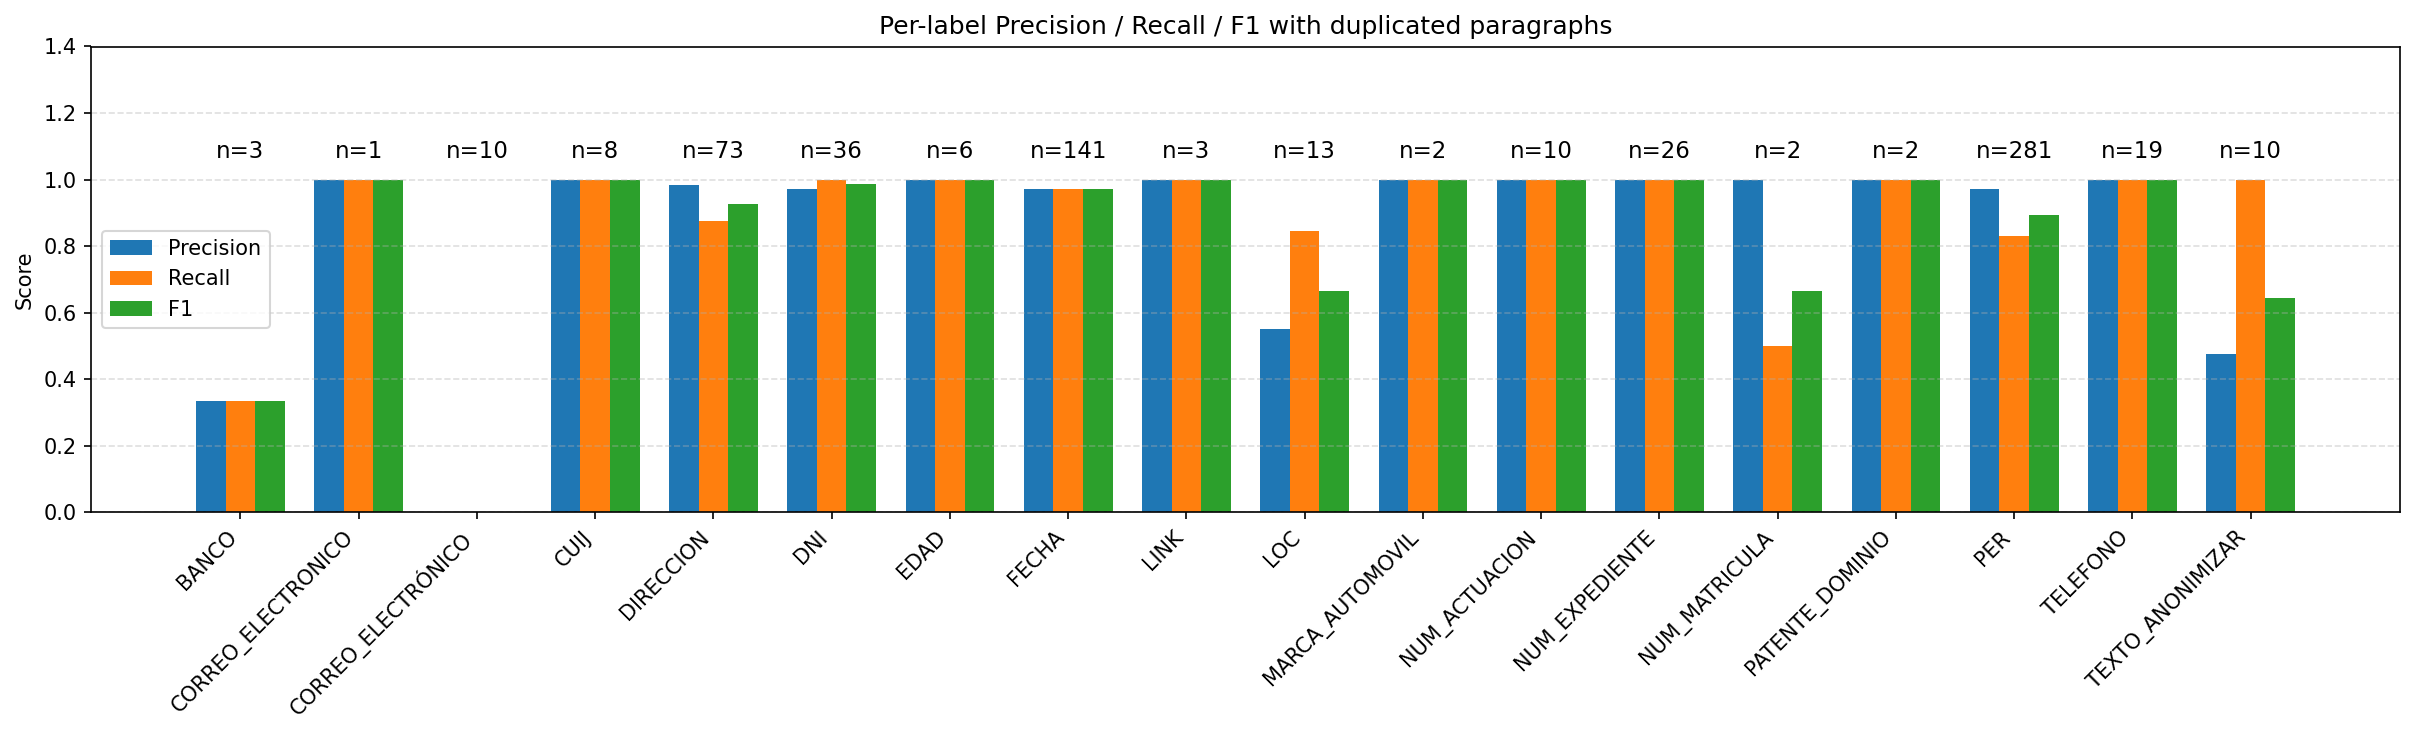

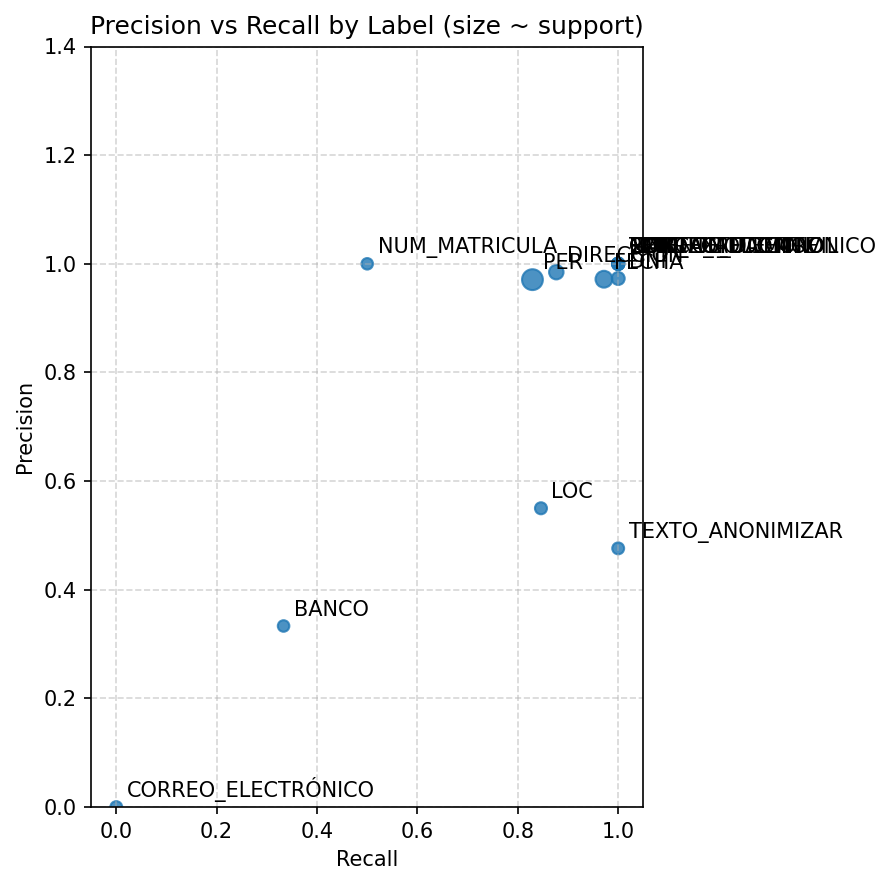

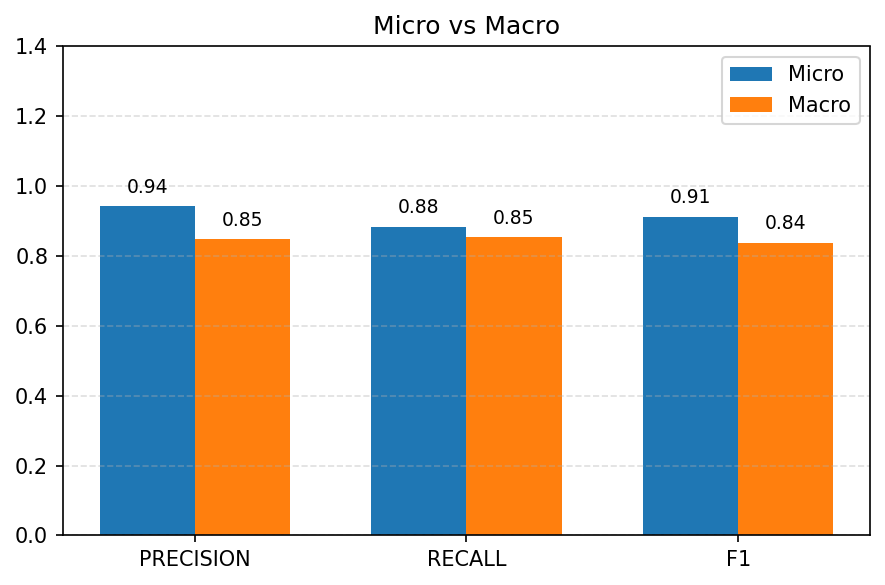

In [66]:
out = metrics_per_entity_by_span(df_main)
plot_per_label_bars(out, top=None, sort_by='support', aclaration_title = 'with duplicated paragraphs',alphabetical = True)
plot_pr_scatter(out, min_support=1, annotate_top=None)
plot_micro_macro(out)

In [67]:
set(df_main.paragraph_id) - set(df_main_dropdup.paragraph_id)

set()

#### Without duplicated paragraph 

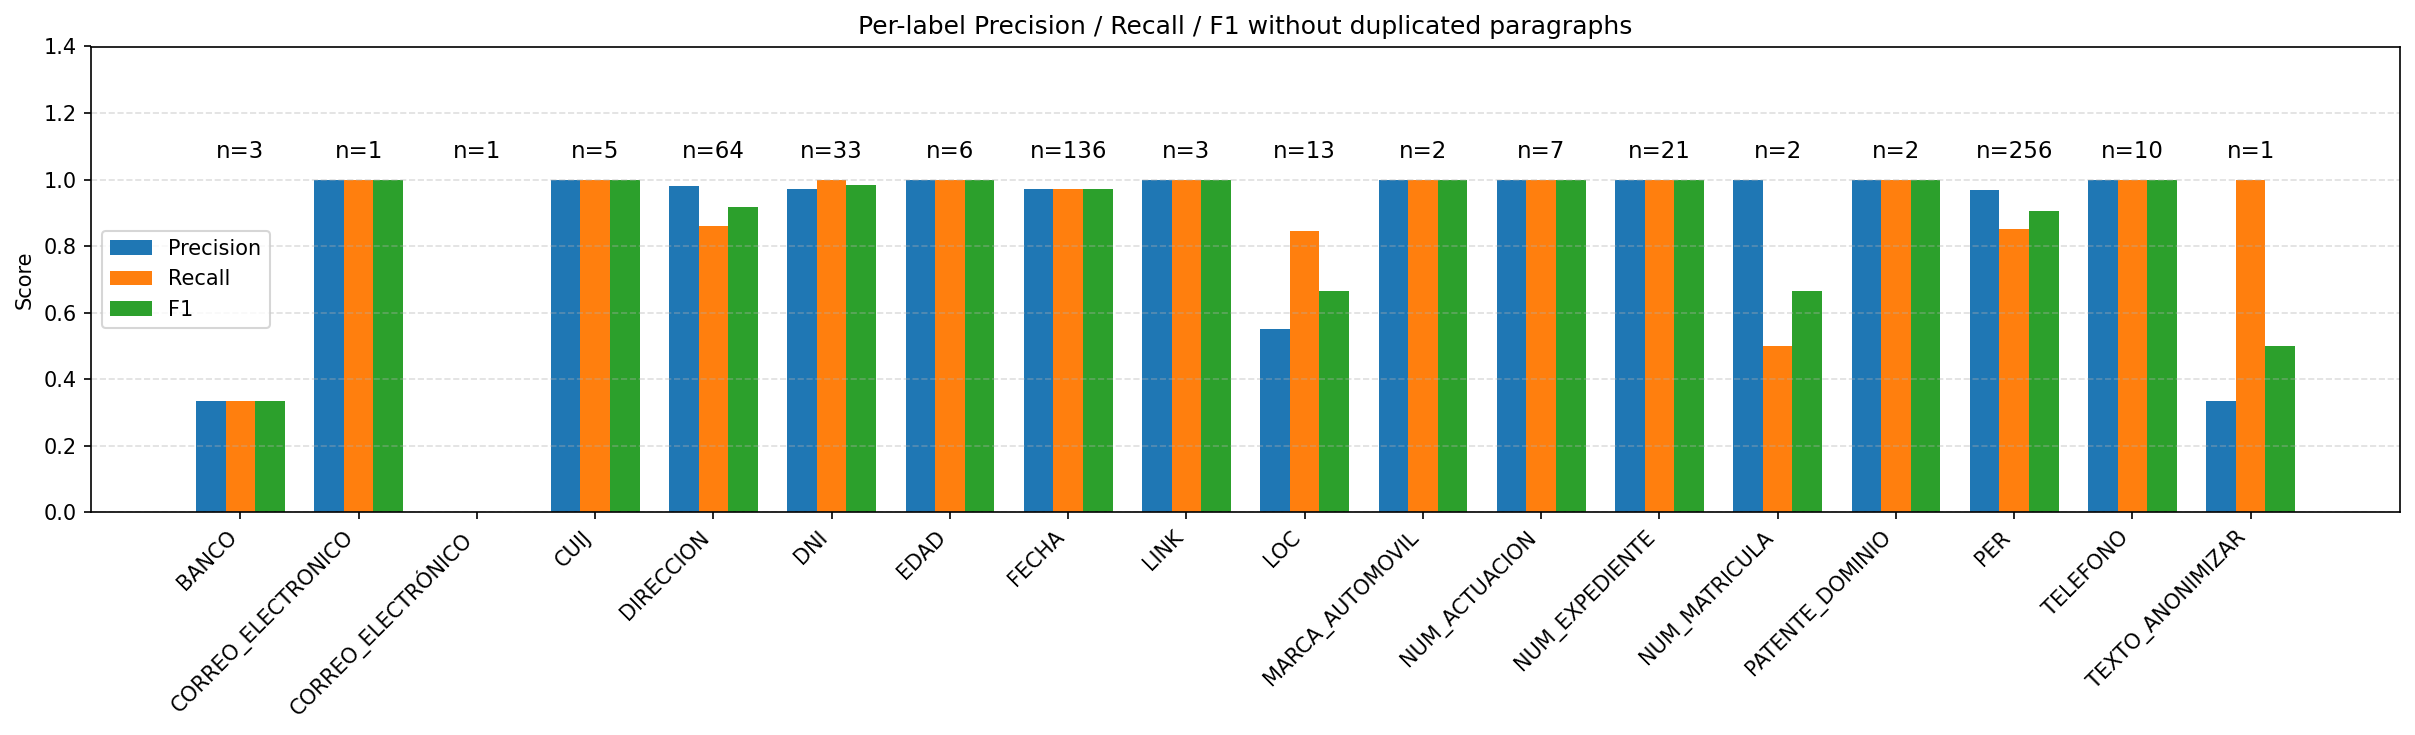

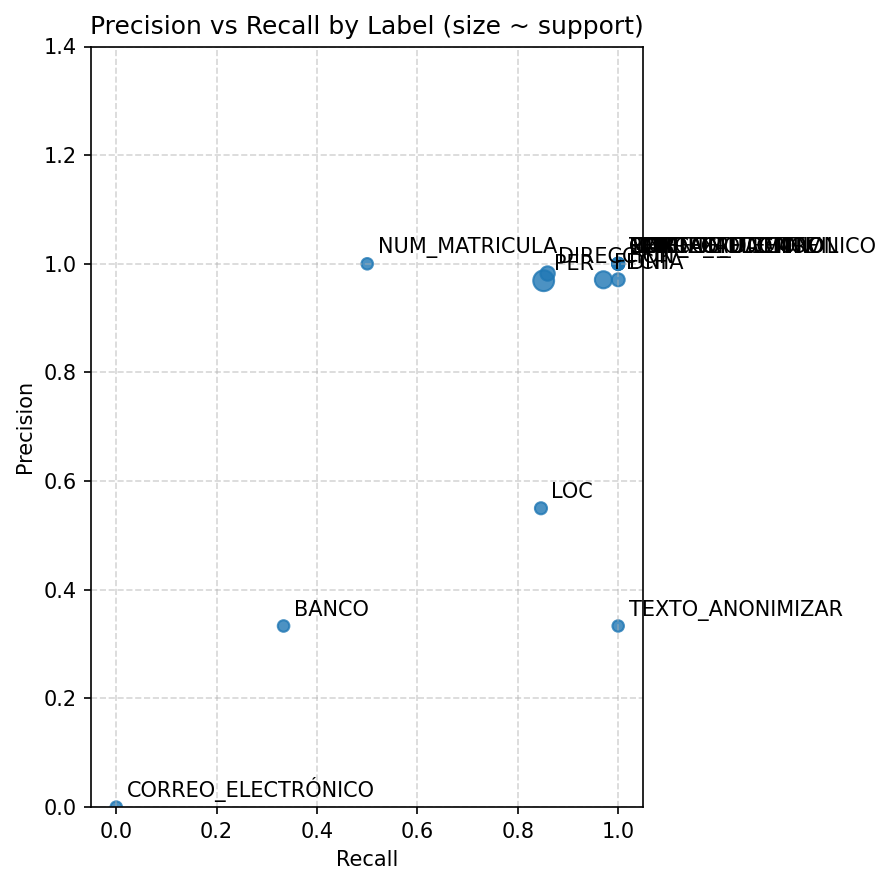

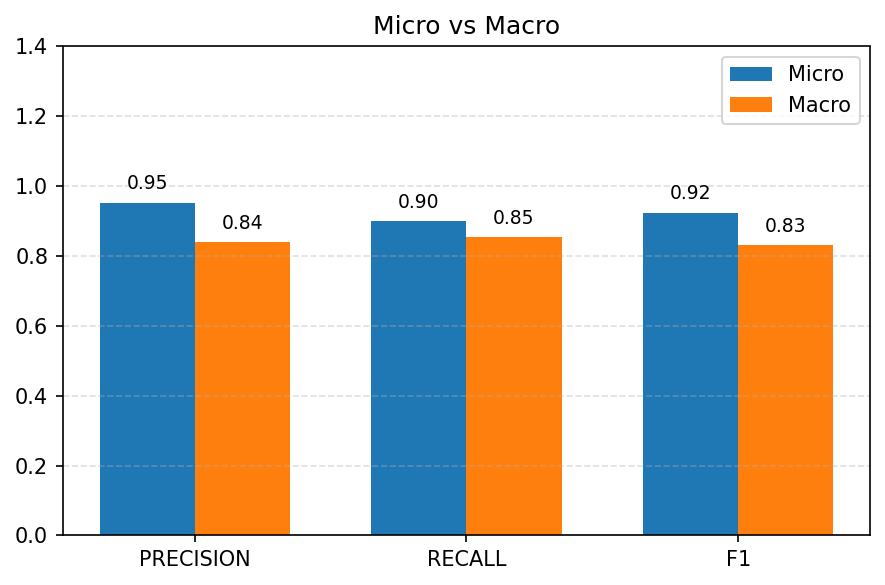

In [68]:
out = metrics_per_entity_by_span(df_main_dropdup)
plot_per_label_bars(out, top=None, sort_by='support', aclaration_title = 'without duplicated paragraphs',alphabetical = True)
plot_pr_scatter(out, min_support=1, annotate_top=None)
plot_micro_macro(out)

In [69]:
out['per_label'].keys()

dict_keys(['DIRECCION', 'TELEFONO', 'CORREO_ELECTRÓNICO', 'TEXTO_ANONIMIZAR', 'NUM_ACTUACION', 'NUM_EXPEDIENTE', 'PER', 'CUIJ', 'DNI', 'FECHA', 'CORREO_ELECTRONICO', 'LINK', 'LOC', 'EDAD', 'BANCO', 'NUM_MATRICULA', 'PATENTE_DOMINIO', 'MARCA_AUTOMOVIL'])

#### OpenAI + LangExtract metrics

##### Set docs from pedictions_openai

##### Old

Lo que haremos en esta sección es matcheat cada prediccion dentro del archivo de prediction, el cual contiene un unido conjunto de labels para todo le documento, con el parrafo al que corresponde. Para ello usaremos df (que tiene text, paragraph_id), y asociaremos primero un numero de orden y longitud a cada parrafo por documento. De esta manera podremos reescribir el output de langextract para poder comparar cada label con su respectivo validation value.

In [86]:
df_main.head(2)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx


In [173]:
df_main_openai = df_main.copy()

Create order and lenght paragraph columns

In [174]:
df_main_openai['paragraph_order'] = df_main_openai.groupby('name').cumcount()
df_main_openai['paragraph_length'] = df_main_openai['text'].apply(len)
df_main_openai.head(3)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_order,paragraph_length
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,0,85
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,0,85
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,0,85


In [ ]:
# Chequeo que el orden de los parrafos este bien por documento
np.sum(df_main_openai.groupby(['paragraph_id','paragraph_order']).nunique().text != 1)

0

Creat start_char and end_char columns

In [175]:
#df_main_openai = df_main_openai.sort_values(['name', 'paragraph_order'], ignore_index=True)
df_main_openai['end_char'] = df_main_openai.groupby('name')['paragraph_length'].cumsum()
df_main_openai['start_char'] = df_main_openai['end_char'] - df_main_openai['paragraph_length']
df_main_openai.head(5)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_order,paragraph_length,end_char,start_char
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,0,85,85,0
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,0,85,85,0
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,0,85,85,0
3,ANTECEDENTES,[],[],adee5f8144eb5e78abb3c56121e906cd,2025-08-08 19:40:02-03:00,2025-08-08 19:40:45-03:00,b31e11b3cff24069b7cf3faa666fbdec,0aec75365ad0511698f72bacb8b88212,adee5f8144eb5e78abb3c56121e906cd,NaN,2025-08-22 19:41:55-03:00,document-03.docx,0,12,12,0
4,ANTECEDENTES,[],[],adee5f8144eb5e78abb3c56121e906cd,2025-08-08 19:40:02-03:00,2025-08-08 19:40:45-03:00,4abeb6f8ff3340cb99cfe61b16276012,518a7f34ad865b91ad95d954093f091a,adee5f8144eb5e78abb3c56121e906cd,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,12,97,85


Create prediction_openai column

In [176]:
def extract_documents(df,text_col = 'text',doc_col = 'name'):
    document_texts = {}
    for doc_name in set(df[doc_col]):
        doc_df = df[df['name']==doc_name]
        doc_text = " ".join(doc_df[text_col])
        document_texts[doc_name] = doc_text
    return document_texts
document_texts = extract_documents(df_main)
document_texts

{'document-02.docx': 'JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVENCIONAL Y DE FALTAS N°10 SECRETARIA N°19 ANTECEDENTES Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10 2022 -Año del 40° Aniversario de la Guerra de Malvinas. En homenaje a los veteranos y caídos en la defensa de las Islas Malvinas y el Atlántico Sur ARGUMENTOS Por lo expuesto, DECIDO: GOMEZ, MATIAS SOBRE 52 - HOSTIGAR, INTIMIDAR Número: IPP 132479/2022-0 Actuación Nro: 2002099/2022 CUIJ: IPP J-01-00132479-5/2022-0 CONVALIDA ARCHIVO POR INIMPUTABILIDAD Convalida el archivo fiscal por inimputabilidad (art. 211 inc. c) del Código Procesal Penal CABA, en adelante CPP y art. 34 inc. 1 del Código Penal, en adelante CP) – Mantiene medidas cautelares conforme Ley 26485 por el contexto de violencia de género en que se sucedieron los hechos. Buenos Aires, 29 de julio de 2022. Reingresó el caso en virtud de la solicitud del señor Fiscal de que se convalide el archivo por inimputabili

In [ ]:
def get_paragraph_predictions(row):
    preds = predictions.get(row['name'], [])
    return [
        p for p in preds
        if p['start_char'] >= (row['start_char'] + row['paragraph_order']) and p['end_char'] <= (row['end_char']+ row['paragraph_order'])
    ]

df_main_openai['prediction_openai_bis'] = df_main_openai.apply(get_paragraph_predictions, axis=1)

errores = df_main_openai[(df_main_openai['validation'] != '[]') & (df_main_openai['prediction_openai_bis'].apply(len) == 0)]


In [188]:
'''
out_openai = metrics_per_entity_by_span(df_main_openai)
plot_per_label_bars(out_openai, top=18, sort_by='support')
plot_pr_scatter(out_openai, min_support=1, annotate_top=18)
plot_micro_macro(out_openai)
'''

"\nout_openai = metrics_per_entity_by_span(df_main_openai)\nplot_per_label_bars(out_openai, top=18, sort_by='support')\nplot_pr_scatter(out_openai, min_support=1, annotate_top=18)\nplot_micro_macro(out_openai)\n"